In [111]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import skimage as sk
import scipy as scipy


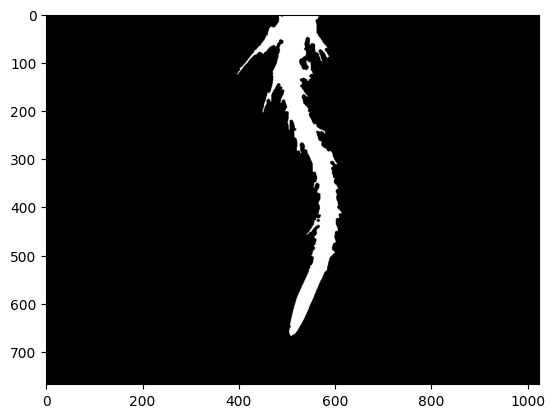

In [112]:
# import image
image_path = '/Users/antoantony/9-30/KO/KO 10 um T0/KO 10 um_1.bmp'
image_gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# turn it black/white
_, mask = cv2.threshold(image_gray, 110, 255, cv2.THRESH_BINARY_INV)

# 4x4 kernel with adaptive threshold (this actually seems to make it worse, so maybe ignore this part)
# kernel4x4 = np.ones((4,4), np.uint8)
# adapt = cv2.adaptiveThreshold(image_gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY_INV, 35, 8)
# # The last two numbers are the block size and the constant subtracted from the mean, respectively. You can adjust these parameters to see how they affect the result.
# adaptive_thresholded = cv2.morphologyEx(adapt, cv2.MORPH_OPEN, kernel4x4)

# connected component
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)
largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])  # Skip the background label

CC_mask = np.zeros_like(mask)
CC_mask[labels == largest_label] = 255

# Morphological closing to fill holes
kernel7x7 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))
closed_mask = cv2.morphologyEx(CC_mask, cv2.MORPH_CLOSE, kernel7x7)

contours, _ = cv2.findContours(closed_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
mask_closed_contour = np.zeros_like(closed_mask)
cv2.drawContours(mask_closed_contour, contours, -1, 255, -1)

plt.imshow(mask_closed_contour, cmap='gray')
plt.show()

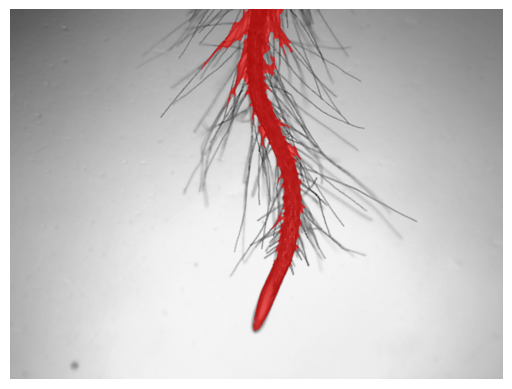

In [113]:
# Create overlay

img_rgb = cv2.cvtColor(image_gray, cv2.COLOR_GRAY2RGB)
mask_rgb = cv2.cvtColor(mask_closed_contour, cv2.COLOR_GRAY2RGB)

overlay = img_rgb.copy()
overlay[mask_closed_contour == 255] = [255, 0, 0]  # Red color for the mask area

alpha = 0.4  # Transparency factor
final_overlay = cv2.addWeighted(img_rgb, alpha, overlay, 1 - alpha, 0)

plt.imshow(final_overlay)
plt.axis('off')
plt.show()

In [ ]:
# Create new mask for root hairs using adaptive thresholding

better_adapt = cv2.adaptiveThreshold(image_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 8)
root_hair_mask = better_adapt.copy()
expanded_root_mask = cv2.dilate(mask_closed_contour, np.ones((10,10), np.uint8), iterations=1)
root_hair_mask[expanded_root_mask > 0] = 0
# root_hair_mask[mask_closed_contour > 0] = 0

# Skeletonize the root hair mask
skeletonized_hairs = sk.morphology.skeletonize(root_hair_mask // 255)
skeletonized_hairs = (skeletonized_hairs * 255).astype(np.uint8)

# Add main root boundary countour to skeletonized hairs to make a version with contours
skeletonized_hairs_with_contours = skeletonized_hairs.copy()
skeletonized_hairs_with_contours = cv2.drawContours(skeletonized_hairs_with_contours, contours, -1, 255, 1)

# Connected component analysis on skeletonized hairs
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(skeletonized_hairs, connectivity=8)
'''I think I need to consider finding alternatives to connectedComponents
It looks like it isn't able to distinguish the individual root hairs. 
Other options Google has recommended:
- cv2.findContours
- cv2.simpleBlobDetector
- skimage.measure.label
- skimage.measure.regionprops
- skan (specifically for skeletons)'''

temporaryStoreOfComponentMasksAndLengths = []
final_lengths = []
component_masks = {}
microscope_conversion_factor = 3.3  # microns per pixel. This needs to be a variable for the user
for i in range(1, num_labels):  # Skip the background label
    component_mask = np.zeros_like(skeletonized_hairs)
    component_mask[labels == i] = 1
    binary_component = (component_mask > 0).astype(np.uint8)

    # temporary for testing
    display_mask = (binary_component * 255).astype(np.uint8)
    display_mask = cv2.dilate(display_mask, np.ones((3,3), np.uint8), iterations=1)
    # temporary for testing 


    kernel = np.array([[1, 1, 1],
                        [1, 0, 1],
                        [1, 1, 1]], dtype=np.uint8)
                    # kernel counts how many neighbors are equal to 1
    neighbor_count = cv2.filter2D(binary_component, -1, kernel, borderType=cv2.BORDER_CONSTANT)
    neighbor_count *= binary_component # keep counts only on skeleton pixels

    if np.any(neighbor_count > 2):
        continue # Skip this component if it has any intersection points 

    endpoints = np.sum(neighbor_count == 1)
    if endpoints != 2:
        continue # Skip this component if it doesn't have exactly 2 endpoints

    # Left with components with only endpoints and boundary points. Calculate length of each 
    diag_kernel = np.array([[1, 0, 1],
                            [0, 0, 0],
                            [1, 0, 1]], dtype=np.uint8)
    diag_counts = scipy.ndimage.convolve(binary_component, diag_kernel, mode='constant') * binary_component
    n_diag = np.sum(diag_counts) / 2 # Each diagonal neighbor is counted twice in the convolution

    n_total = np.sum(neighbor_count) / 2
    n_ortho = n_total - n_diag

    length = (n_ortho * 1.0) + (n_diag * np.sqrt(2))
    length = length * microscope_conversion_factor
    # if length.any() > 100 or length.any() < 10:
    #     continue # Skip this component if the length is outside of expected range for root hairs

    final_lengths.append({
        "component_id": i,
        "length_microns": length * microscope_conversion_factor,
        "num_pixels": int(np.sum(binary_component)),
        "num_endpoints": int(endpoints)
    })
    component_masks[i] = binary_component.copy()

    temporaryStoreOfComponentMasksAndLengths.append(
        {
            'component_id': i,
            'component_mask': component_mask,
            'binary_component': binary_component,
            'display_mask': display_mask,
            'neighbor_count': neighbor_count,
            'diag_kernel': diag_kernel,
            'diag_counts': diag_counts,
            'n_diag': n_diag,
            'n_total': n_total,
            'n_ortho': n_ortho,
            'length': length
        }
    )
    fig, axs = plt.subplots(1, 4, figsize=(20, 5))  
    axs[0].imshow(root_hair_mask, cmap='gray')
    axs[0].set_title('Root Hair Mask')
    axs[0].axis('off')
    axs[1].imshow(skeletonized_hairs, cmap='gray')
    axs[1].set_title('Skeletonized Hairs')
    axs[1].axis('off')
    axs[2].imshow(display_mask, cmap='gray')
    axs[2].set_title('Current Component Mask')
    axs[2].axis('off')
    axs[3].imshow(neighbor_count, cmap='gray')
    axs[3].set_title('Neighbor Count')
    axs[3].axis('off')
    plt.tight_layout()
    plt.show()

    plt.imshow(skeletonized_hairs, cmap='gray')
    plt.title('Skeletonized Hairs')
    plt.axis('off')
    plt.show()
    plt.imshow(binary_component, cmap='gray')
    plt.title('Binary Component')
    plt.axis('off')
    plt.show()
    # answer = input("Put continue to continue or exit:")
    # if answer == "continue":
    #     continue
    # elif answer == "exit":
    #     break


In [ ]:
'''I think I need to consider finding alternatives to connectedComponents
It looks like it isn't able to distinguish the individual root hairs. 
Other options Google has recommended:
- cv2.findContours
- cv2.simpleBlobDetector
- skimage.measure.label
- skimage.measure.regionprops
- skan (specifically for skeletons)'''

25


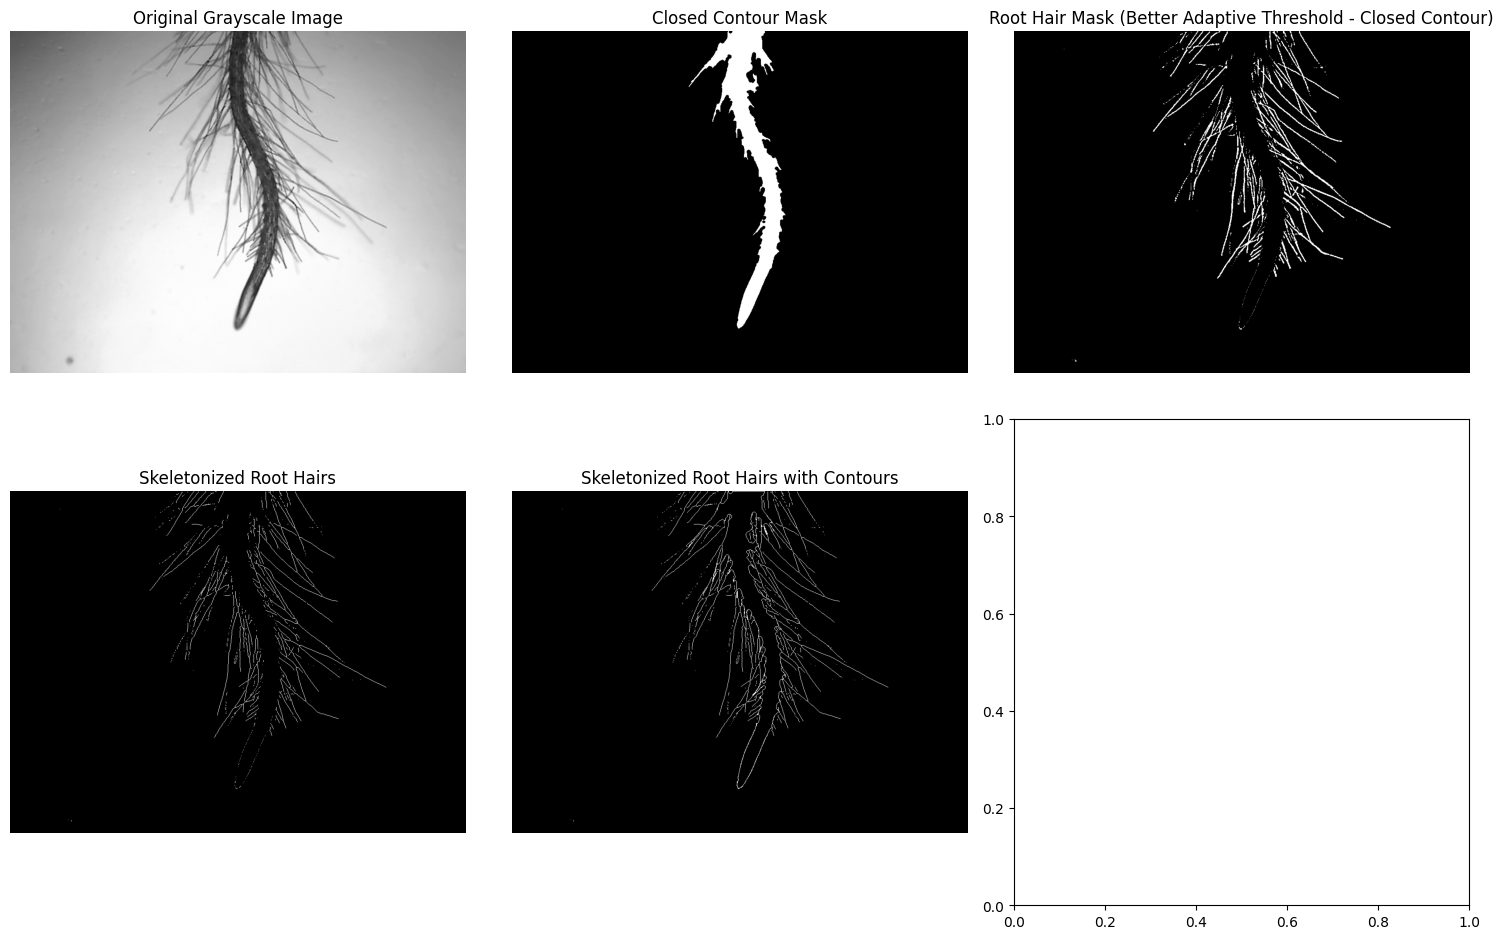

In [ ]:
fig, ax = plt.subplots(2, 3, figsize=(15, 10))
ax[0, 0].imshow(image_gray, cmap='gray')
ax[0, 0].set_title('Original Grayscale Image')
ax[0, 0].axis('off')
ax[0, 1].imshow(mask_closed_contour, cmap='gray')
ax[0, 1].set_title('Closed Contour Mask')
ax[0, 1].axis('off')
ax[0, 2].imshow(root_hair_mask, cmap='gray')
ax[0, 2].set_title('Root Hair Mask (Better Adaptive Threshold - Closed Contour)')
ax[0, 2].axis('off')
ax[1, 0].imshow(skeletonized_hairs, cmap='gray')
ax[1, 0].set_title('Skeletonized Root Hairs')
ax[1, 0].axis('off')
ax[1, 1].imshow(skeletonized_hairs_with_contours, cmap='gray')
ax[1, 1].set_title('Skeletonized Root Hairs with Contours')
ax[1, 1].axis('off')
plt.tight_layout()
plt.show()